In [1]:
!pip install mediapipe -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 4.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# Dataset Link

# https://drive.google.com/drive/folders/1RdFLeJ66Qq_8-60qwTNTnBSuhWUYacYZ?usp=sharing

BASE = "/content/drive/MyDrive/YawDD-dataset/YawDD dataset"

MIRROR_MALE   = os.path.join(BASE, "Mirror", "Male_mirror Avi Videos")
MIRROR_FEMALE = os.path.join(BASE, "Mirror", "Female_mirror")
DASH_MALE     = os.path.join(BASE, "Dash", "Male")
DASH_FEMALE   = os.path.join(BASE, "Dash", "Female")

for name, path in [("Mirror-Male", MIRROR_MALE), ("Mirror-Female", MIRROR_FEMALE),
                    ("Dash-Male", DASH_MALE), ("Dash-Female", DASH_FEMALE)]:
    if os.path.exists(path):
        files = os.listdir(path)
        print(f"{name}: {len(files)} files, e.g. {files[0] if files else 'EMPTY'}")
    else:
        print(f"{name}: PATH NOT FOUND")

Mirror-Male: 164 files, e.g. 1-MaleNoGlasses-Yawning.avi
Mirror-Female: 156 files, e.g. 1-FemaleNoGlasses-Normal.avi
Dash-Male: 16 files, e.g. 1-MaleGlasses.avi
Dash-Female: 13 files, e.g. 1-FemaleNoGlasses.avi


In [4]:
for root, dirs, files in os.walk("/content/drive/MyDrive/YawDD-dataset/YawDD dataset"):
    level = root.replace(BASE, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if files:
        print(f"{indent}  -> {len(files)} files, e.g. {files[0]}")
    if level > 2:  # don't recurse too deep / print too much
        dirs.clear()

YawDD dataset/
  -> 3 files, e.g. Readme_YawDD.pdf
  Dash/
    Male/
      -> 16 files, e.g. 1-MaleGlasses.avi
    Female/
      -> 13 files, e.g. 1-FemaleNoGlasses.avi
  Mirror/
    Male_mirror Avi Videos/
      -> 164 files, e.g. 1-MaleNoGlasses-Yawning.avi
    Female_mirror/
      -> 156 files, e.g. 1-FemaleNoGlasses-Normal.avi


In [5]:

import cv2

def grab_sample_frame(folder, filename, out_name):
    path = os.path.join(folder, filename)
    cap = cv2.VideoCapture(path)
    ret, frame = cap.read()
    if ret:
        cv2.imwrite(out_name, frame)
        print(f"{out_name}: shape {frame.shape}")
    else:
        print(f"Failed to read: {path}")
    cap.release()

grab_sample_frame(MIRROR_MALE, "34-MaleNoGlasses-Yawning.avi", "/content/mirror_sample.jpg")
grab_sample_frame(DASH_MALE, "5-MaleGlasses.avi", "/content/dash_sample.jpg")

/content/mirror_sample.jpg: shape (480, 640, 3)
/content/dash_sample.jpg: shape (480, 640, 3)


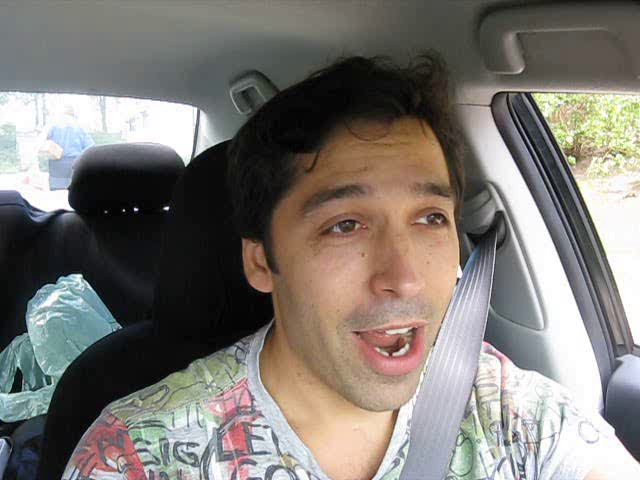

In [6]:
from google.colab.patches import cv2_imshow
import cv2

mirror_img = cv2.imread("/content/mirror_sample.jpg")
cv2_imshow(mirror_img)

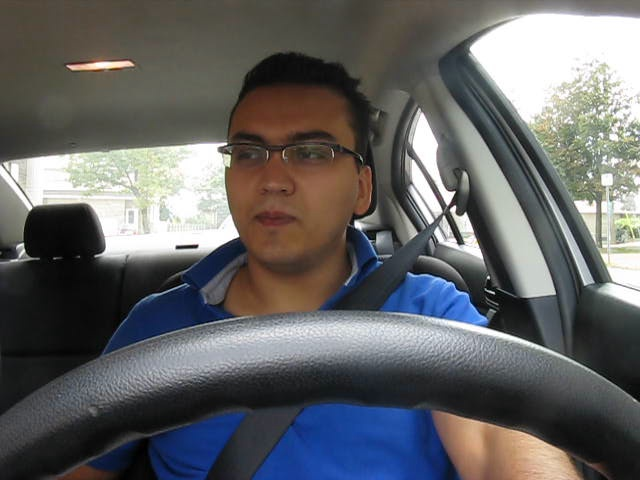

In [7]:
dash_img = cv2.imread("/content/dash_sample.jpg")
cv2_imshow(dash_img)

# EDA

In [8]:
!wget -q -O face_landmarker.task https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

In [9]:
import shutil
shutil.copy("face_landmarker.task", "/content/drive/MyDrive/YawDD-dataset/face_landmarker.task")

'/content/drive/MyDrive/YawDD-dataset/face_landmarker.task'

In [10]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2
import os
import pandas as pd

# ---- 1. Detector setup (reuse across all videos) ----
base_options = python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=True,
    num_faces=1,
    running_mode=vision.RunningMode.IMAGE
)
detector = vision.FaceLandmarker.create_from_options(options)

In [11]:
# ---- 2. Pilot video set ----
pilot_videos = [
    (MIRROR_MALE, "34-MaleNoGlasses-Yawning.avi"),
    (MIRROR_FEMALE, os.listdir(MIRROR_FEMALE)[0]),
    (MIRROR_MALE, os.listdir(MIRROR_MALE)[1]),
    (MIRROR_FEMALE, os.listdir(MIRROR_FEMALE)[1]),
    (DASH_MALE, "5-MaleGlasses.avi"),
    (DASH_FEMALE, os.listdir(DASH_FEMALE)[0]),
    (DASH_MALE, os.listdir(DASH_MALE)[1]),
]

print("Pilot videos selected:")
for folder, fname in pilot_videos:
    print(" -", fname)

os.makedirs("/content/failures", exist_ok=True)
os.makedirs("/content/success_samples", exist_ok=True)

log_rows = []

Pilot videos selected:
 - 34-MaleNoGlasses-Yawning.avi
 - 1-FemaleNoGlasses-Normal.avi
 - 1-MaleSunGlasses-Yawning.avi
 - 1-FemaleNoGlasses-Yawning.avi
 - 5-MaleGlasses.avi
 - 1-FemaleNoGlasses.avi
 - 9-MaleNoGlasses.avi


In [12]:
!apt-get install unrar -y -q  # skip if already done
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2, os, re, glob
import pandas as pd
import numpy as np



Reading package lists...
Building dependency tree...
Reading state information...
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [13]:
# ---- Enable GPU delegate (falls back gracefully if unavailable) ----
try:
    base_options = python.BaseOptions(
        model_asset_path='face_landmarker.task',
        delegate=python.BaseOptions.Delegate.GPU
    )
    options = vision.FaceLandmarkerOptions(
        base_options=base_options, num_faces=1,
        output_facial_transformation_matrixes=True,
        running_mode=vision.RunningMode.IMAGE
    )
    detector = vision.FaceLandmarker.create_from_options(options)
    print("Using GPU delegate")
except Exception as e:
    print("GPU failed, falling back to CPU:", e)
    base_options = python.BaseOptions(model_asset_path='face_landmarker.task')

    options = vision.FaceLandmarkerOptions(
        base_options=base_options, num_faces=1,
        output_facial_transformation_matrixes=True,
        running_mode=vision.RunningMode.IMAGE
    )
    detector = vision.FaceLandmarker.create_from_options(options)




GPU failed, falling back to CPU: Service "kGpuService", required by node mediapipe_tasks_vision_face_landmarker_facelandmarkergraph__mediapipe_tasks_vision_face_detector_facedetectorgraph__mediapipe_tasks_core_inferencesubgraph__inferencecalculator__mediapipe_tasks_vision_face_landmarker_facelandmarkergraph__mediapipe_tasks_vision_face_detector_facedetectorgraph__mediapipe_tasks_core_inferencesubgraph__InferenceCalculator, was not provided and cannot be created: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:84) egl_initializedUnable to initialize EGL


In [14]:
# ---- Collect all videos + parse metadata from filename ----
def parse_filename(fname, camera):
    m = re.match(r"(\d+)-(Male|Female)(NoGlasses|Glasses|SunGlasses)-?(\w+)?\.avi", fname)
    if m:
        subj, gender, glasses, action = m.groups()
        return subj, gender, glasses, action or "Unknown", camera
    return "Unknown", "Unknown", "Unknown", "Unknown", camera

all_videos = []
for folder, cam in [(MIRROR_MALE,"Mirror"), (MIRROR_FEMALE,"Mirror"),
                     (DASH_MALE,"Dash"), (DASH_FEMALE,"Dash")]:
    for fname in os.listdir(folder):
        if fname.endswith(".avi"):
            all_videos.append((folder, fname, cam))

print(f"Total videos: {len(all_videos)}")


Total videos: 349


In [17]:
log_dir = "/content/drive/MyDrive/YawDD-dataset/extraction_logs"
sample_dir = "/content/drive/MyDrive/YawDD-dataset/eda_samples"

In [18]:
# ---- Checkpointed per-video processing ----

os.makedirs(log_dir, exist_ok=True)
os.makedirs(f"{sample_dir}/success", exist_ok=True)
os.makedirs(f"{sample_dir}/failure", exist_ok=True)

processed = set(os.path.basename(f).replace("_log.csv","") for f in glob.glob(f"{log_dir}/*_log.csv"))

for folder, filename, camera in all_videos:
    if filename in processed:
        continue

    subj, gender, glasses, action, cam = parse_filename(filename, camera)
    path = os.path.join(folder, filename)
    cap = cv2.VideoCapture(path)
    frame_idx = 0
    rows = []
    saved_s, saved_f = False, False

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        h, w, _ = frame.shape
        brightness = np.mean(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY))  # lighting proxy

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        result = detector.detect(mp_image)
        detected = len(result.face_landmarks) > 0

        rows.append({
            "video": filename, "frame_idx": frame_idx, "face_detected": detected,
            "brightness": brightness, "subject": subj, "gender": gender,
            "glasses": glasses, "action": action, "camera": cam
        })

        if detected and not saved_s:
            cv2.imwrite(f"{sample_dir}/success/{filename}_{frame_idx}.jpg", frame)
            saved_s = True
        if not detected and not saved_f:
            cv2.imwrite(f"{sample_dir}/failure/{filename}_{frame_idx}.jpg", frame)
            saved_f = True

        frame_idx += 1

    cap.release()
    pd.DataFrame(rows).to_csv(f"{log_dir}/{filename}_log.csv", index=False)
    print(f"Done: {filename} ({frame_idx} frames, camera={cam}, glasses={glasses})")

print("\nFull dataset processing complete (or resumed to completion).")

Done: 1-MaleNoGlasses-Yawning.avi (441 frames, camera=Mirror, glasses=NoGlasses)
Done: 1-MaleSunGlasses-Yawning.avi (442 frames, camera=Mirror, glasses=SunGlasses)
Done: 1-MaleNoGlasses-Talking.avi (726 frames, camera=Mirror, glasses=NoGlasses)
Done: 2-MaleGlasses-Normal.avi (451 frames, camera=Mirror, glasses=Glasses)
Done: 2-MaleGlasses-Yawning.avi (429 frames, camera=Mirror, glasses=Glasses)
Done: 2-MaleGlasses-Talking.avi (552 frames, camera=Mirror, glasses=Glasses)
Done: 3-MaleGlasses-Normal.avi (766 frames, camera=Mirror, glasses=Glasses)
Done: 3-MaleGlasses-Yawning.avi (523 frames, camera=Mirror, glasses=Glasses)
Done: 3-MaleNoGlasses-Normal.avi (369 frames, camera=Mirror, glasses=NoGlasses)
Done: 3-MaleGlasses-Talking.avi (1015 frames, camera=Mirror, glasses=Glasses)
Done: 3-MaleNoGlasses-Yawning.avi (596 frames, camera=Mirror, glasses=NoGlasses)
Done: 4-MaleNoGlasses-Normal.avi (395 frames, camera=Mirror, glasses=NoGlasses)
Done: 4-MaleNoGlasses-Talking.avi (407 frames, camera

In [18]:
all_logs = glob.glob(f"{log_dir}/*_log.csv")
full_df = pd.concat([pd.read_csv(f) for f in all_logs], ignore_index=True)
full_df.to_csv("/content/drive/MyDrive/YawDD-dataset/full_detection_log.csv", index=False)

print("=== Overall success rate ===")
print(full_df["face_detected"].mean())

print("\n=== Success rate by camera angle ===")
print(full_df.groupby("camera")["face_detected"].mean())

print("\n=== Success rate by eyewear ===")
print(full_df.groupby("glasses")["face_detected"].mean())

print("\n=== Success rate by gender ===")
print(full_df.groupby("gender")["face_detected"].mean())

print("\n=== Brightness (lighting) range per camera ===")
print(full_df.groupby("camera")["brightness"].describe())

print(f"\nTotal videos processed: {full_df['video'].nunique()}")
print(f"Total frames processed: {len(full_df)}")

=== Overall success rate ===
0.9934622832038976

=== Success rate by camera angle ===
camera
Dash      0.994814
Mirror    0.993072
Name: face_detected, dtype: float64

=== Success rate by eyewear ===
glasses
Glasses       0.992091
NoGlasses     0.993929
SunGlasses    0.990775
Unknown       0.999648
Name: face_detected, dtype: float64

=== Success rate by gender ===
gender
Female     0.993451
Male       0.992564
Unknown    0.999648
Name: face_detected, dtype: float64

=== Brightness (lighting) range per camera ===
           count        mean        std        min         25%         50%  \
camera                                                                       
Dash     64593.0  104.286449  11.786992  48.450443   98.203757  106.310729   
Mirror  223581.0  112.238403  12.932858  53.624746  102.537565  112.505007   

               75%         max  
camera                          
Dash    111.434508  138.623193  
Mirror  122.557321  156.976354  

Total videos processed: 349
Total f

=== Overall success rate ===
 0.9934622832038976

=== Success rate by camera angle ===
camera
Dash      0.994814
Mirror    0.993072
Name: face_detected, dtype: float64

=== Success rate by eyewear ===
glasses
Glasses       0.992091
NoGlasses     0.993929
SunGlasses    0.990775
Unknown       0.999648
Name: face_detected, dtype: float64

=== Success rate by gender ===
gender
Female     0.993451
Male       0.992564
Unknown    0.999648
Name: face_detected, dtype: float64

=== Brightness (lighting) range per camera ===
           count        mean        std        min         25%         50%  \
camera                                                                       
Dash     64593.0  104.286449  11.786992  48.450443   98.203757  106.310729   
Mirror  223581.0  112.238403  12.932858  53.624746  102.537565  112.505007   

               75%         max  
camera                          
Dash    111.434508  138.623193  
Mirror  122.557321  156.976354  

Total videos processed: 349
Total frames processed: 288174

In [19]:
print(full_df[full_df["glasses"]=="Unknown"]["video"].unique())
print(f"\nCount of Unknown videos: {full_df[full_df['glasses']=='Unknown']['video'].nunique()}")

['8-MaleGlassesBeard-Normal.avi' '8-MaleGlassesBeard-Talking.avi'
 '8-MaleGlassesBeard-Yawning.avi' '19-MaleGlassesmoustache-Normal.avi'
 '19-MaleGlassesmoustache-Yawning.avi'
 '19-MaleGlassesmoustache-Talking.avi'
 '22-MaleGlassesmoustache-Normal.avi' '20-MaleGlasses-Talking&yawning.avi'
 '23-MaleGlassesBeard-Talking&Yawning.avi'
 '22-MaleGlassesmoustache-Talking.avi'
 '22-MaleGlassesmoustache-Yawning.avi' '23-MaleGlassesBeard-Normal.avi'
 '23-MaleGlassesBeard-Talking.avi' '23-MaleGlassesBeard-Yawning.avi'
 '30-MaleGlasses-Talking&Yawning.avi' '32-MaleGlasses-Talking&Yawning.avi'
 '33-MaleGlasses-Talking&Yawning.avi'
 '19-FemaleNoGlasses-Talking&Yawning.avi'
 '23-FemaleNoGlasses-Talking&Yawning.avi'
 '27-FemaleNoGlasses-Talking&Yawning.avi'
 '34-FemaleNoGlasses-Talking&Yawning.avi'
 '35-FemaleNoGlasses-Talking&Yawning.avi'
 '36-FemaleNoGlasses-Talking&Yawning.avi'
 '37-FemaleNoGlasses-Talking&Yawning.avi'
 '39-FemaleNoGlasses-Talking&Yawning.avi' '13-MaleNoGlasses .avi']

Count of Unk

In [20]:
import re

def parse_filename_v2(fname):
    # normalize: strip extra spaces, handle inconsistent casing in "&"
    clean = fname.strip()

    m = re.match(
        r"(\d+)-(Male|Female)\s*(NoGlasses|SunGlasses|Glasses)(Beard|[Mm]oustache)?-?\s*(.*)\.avi",
        clean
    )
    if m:
        subj, gender, glasses_base, occlusion, action_raw = m.groups()
        occlusion = occlusion if occlusion else "None"
        action = action_raw.strip() if action_raw.strip() else "Unknown"
        # normalize combined actions
        action = action.replace("&", "_").replace(" ", "")
        return subj, gender, glasses_base, occlusion, action
    return "Unknown", "Unknown", "Unknown", "Unknown", "Unknown"

# quick test on the exact filenames that failed before
test_names = [
    "8-MaleGlassesBeard-Normal.avi",
    "19-MaleGlassesmoustache-Yawning.avi",
    "20-MaleGlasses-Talking&yawning.avi",
    "19-FemaleNoGlasses-Talking&Yawning.avi",
    "13-MaleNoGlasses .avi",
]
for t in test_names:
    print(t, "->", parse_filename_v2(t))

8-MaleGlassesBeard-Normal.avi -> ('8', 'Male', 'Glasses', 'Beard', 'Normal')
19-MaleGlassesmoustache-Yawning.avi -> ('19', 'Male', 'Glasses', 'moustache', 'Yawning')
20-MaleGlasses-Talking&yawning.avi -> ('20', 'Male', 'Glasses', 'None', 'Talking_yawning')
19-FemaleNoGlasses-Talking&Yawning.avi -> ('19', 'Female', 'NoGlasses', 'None', 'Talking_Yawning')
13-MaleNoGlasses .avi -> ('13', 'Male', 'NoGlasses', 'None', 'Unknown')


In [29]:
def apply_parse(row):
    subj, gender, glasses, occlusion, action = parse_filename_v2(row["video"])
    return pd.Series({"subject": subj, "gender": gender, "glasses": glasses,
                       "occlusion": occlusion, "action": action})

full_df[["subject","gender","glasses","occlusion","action"]] = full_df.apply(apply_parse, axis=1)

print("Remaining Unknown glasses count:", (full_df["glasses"]=="Unknown").sum())
print("Remaining Unknown videos:", full_df[full_df["glasses"]=="Unknown"]["video"].unique())

full_df.to_csv("/content/drive/MyDrive/YawDD-dataset/full_detection_log_v2.csv", index=False)

Remaining Unknown glasses count: 0
Remaining Unknown videos: []


In [30]:
print("=== Success rate by eyewear (corrected) ===")
print(full_df.groupby("glasses")["face_detected"].mean())

print("\n=== Success rate by occlusion (beard/moustache) ===")
print(full_df.groupby("occlusion")["face_detected"].mean())

print("\n=== Success rate by action ===")
print(full_df.groupby("action")["face_detected"].mean())

print("\n=== Video count per category (sanity check) ===")
print(full_df.groupby("glasses")["video"].nunique())
print(full_df.groupby("occlusion")["video"].nunique())

=== Success rate by eyewear (corrected) ===
glasses
Glasses       0.992928
NoGlasses     0.994221
SunGlasses    0.990775
Name: face_detected, dtype: float64

=== Success rate by occlusion (beard/moustache) ===
occlusion
Beard        1.000000
None         0.993256
moustache    0.999423
Name: face_detected, dtype: float64

=== Success rate by action ===
action
.avi               0.983530
Normal             0.990140
Talking            0.995519
Talking_Yawning    0.999475
Talking_yawning    1.000000
Unknown            0.996637
Yawning            0.991562
Name: face_detected, dtype: float64

=== Video count per category (sanity check) ===
glasses
Glasses       117
NoGlasses     196
SunGlasses     36
Name: video, dtype: int64
occlusion
Beard          7
None         336
moustache      6
Name: video, dtype: int64


# Quality check

feature extraction

In [23]:
import numpy as np
import math

LEFT_EYE  = [362, 385, 387, 263, 373, 380]
RIGHT_EYE = [33, 160, 158, 133, 153, 144]
MOUTH     = [61, 291, 39, 181, 0, 17]

def euclid(p1, p2):
    return math.dist(p1, p2)

def compute_ear(lm, eye_idx, w, h):
    pts = [(lm[i].x*w, lm[i].y*h) for i in eye_idx]
    v1 = euclid(pts[1], pts[5])
    v2 = euclid(pts[2], pts[4])
    horiz = euclid(pts[0], pts[3])
    return (v1 + v2) / (2.0*horiz + 1e-6)

def compute_mar(lm, mouth_idx, w, h):
    pts = [(lm[i].x*w, lm[i].y*h) for i in mouth_idx]
    vert = euclid(pts[2], pts[4])
    horiz = euclid(pts[0], pts[1])
    return vert / (horiz + 1e-6)

def compute_pose_from_matrix(matrix):
    rmat = np.array(matrix)[:3, :3]
    sy = math.sqrt(rmat[0,0]**2 + rmat[1,0]**2)
    pitch = math.degrees(math.atan2(-rmat[2,0], sy))
    yaw   = math.degrees(math.atan2(rmat[1,0], rmat[0,0]))
    roll  = math.degrees(math.atan2(rmat[2,1], rmat[2,2]))
    return pitch, yaw, roll

print("Feature functions loaded successfully")

Feature functions loaded successfully


In [24]:
import os, glob
import pandas as pd
import cv2

feature_dir = "/content/drive/MyDrive/YawDD-dataset/feature_logs"
os.makedirs(feature_dir, exist_ok=True)

processed_features = set(
    os.path.basename(f).replace("_features.csv","")
    for f in glob.glob(f"{feature_dir}/*_features.csv")
)

for folder, filename, camera in all_videos:
    if filename in processed_features:
        continue

    path = os.path.join(folder, filename)
    cap = cv2.VideoCapture(path)
    frame_idx = 0
    rows = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        h, w, _ = frame.shape
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        result = detector.detect(mp_image)

        if result.face_landmarks:
            lm = result.face_landmarks[0]
            ear = (compute_ear(lm, LEFT_EYE, w, h) + compute_ear(lm, RIGHT_EYE, w, h)) / 2
            mar = compute_mar(lm, MOUTH, w, h)

            if result.facial_transformation_matrixes:
                pitch, yaw, roll = compute_pose_from_matrix(result.facial_transformation_matrixes[0])
            else:
                pitch, yaw, roll = np.nan, np.nan, np.nan

            rows.append({"frame_idx": frame_idx, "ear": ear, "mar": mar,
                         "pitch": pitch, "yaw": yaw, "roll": roll, "detected": True})
        else:
            rows.append({"frame_idx": frame_idx, "ear": np.nan, "mar": np.nan,
                         "pitch": np.nan, "yaw": np.nan, "roll": np.nan, "detected": False})

        frame_idx += 1

    cap.release()
    pd.DataFrame(rows).to_csv(f"{feature_dir}/{filename}_features.csv", index=False)
    print(f"Features done: {filename} ({frame_idx} frames)")

print("\nFeature extraction complete (or resumed to completion).")

Features done: 14-MaleGlasses-Talking.avi (921 frames)
Features done: 15-MaleNoGlasses-Talking.avi (763 frames)
Features done: 15-MaleNoGlasses-Yawning.avi (561 frames)
Features done: 16-MaleNoGlasses-Talking.avi (263 frames)
Features done: 16-MaleNoGlasses-Normal.avi (576 frames)
Features done: 17-MaleNoGlasses-Normal.avi (532 frames)
Features done: 17-MaleNoGlasses-Yawning.avi (570 frames)
Features done: 18-MaleNoGlasses-Normal.avi (571 frames)
Features done: 17-MaleNoGlasses-Talking.avi (956 frames)
Features done: 18-MaleNoGlasses-Yawning.avi (525 frames)
Features done: 19-MaleGlassesmoustache-Normal.avi (708 frames)
Features done: 19-MaleGlassesmoustache-Yawning.avi (481 frames)
Features done: 18-MaleNoGlasses-Talking.avi (1029 frames)
Features done: 20-MaleGlasses-Normal.avi (808 frames)
Features done: 21-MaleGlasses-Normal.avi (592 frames)
Features done: 19-MaleGlassesmoustache-Talking.avi (1207 frames)
Features done: 20-MaleGlasses-Talking.avi (832 frames)
Features done: 21-Male

In [25]:
import random
random.seed(42)

# group all_videos by key categories using your metadata
sample_df = full_df[["video","glasses","occlusion","camera","gender","action"]].drop_duplicates("video")

# stratified sample: a few videos per glasses type per camera
sampled_videos = []
for (glasses, camera), group in sample_df.groupby(["glasses","camera"]):
    n = min(20, len(group))  # up to 5 videos per combination
    sampled_videos.extend(group.sample(n, random_state=42)["video"].tolist())

print(f"Sampled {len(sampled_videos)} videos out of 349")

# filter all_videos down to just this sample
all_videos_sample = [(f, fn, c) for f, fn, c in all_videos if fn in sampled_videos]

Sampled 89 videos out of 349


In [26]:
import glob, os
import pandas as pd

feature_dir = "/content/drive/MyDrive/YawDD-dataset/feature_logs"
all_feat_logs = glob.glob(f"{feature_dir}/*_features.csv")

print(f"Found {len(all_feat_logs)} feature log files")

if len(all_feat_logs) == 0:
    print("No feature logs found — you need to run the feature extraction step first (Step 2).")
else:
    feat_df = pd.concat(
        [pd.read_csv(f).assign(video=os.path.basename(f).replace("_features.csv",""))
         for f in all_feat_logs], ignore_index=True
    )
    print("feat_df loaded:", feat_df.shape)

Found 349 feature log files
feat_df loaded: (288174, 8)


In [27]:
import pandas as pd
import numpy as np

# ============================================================
# QUALITY CHECKS — Landmark Feature Extraction (YawDD)
# ============================================================

# ---- Prep: merge feature data with metadata (glasses, occlusion, camera) ----
meta_cols = full_df[["video", "glasses", "occlusion", "camera", "gender", "action"]].drop_duplicates("video")
feat_df_merged = feat_df.merge(meta_cols, on="video", how="left")

# frame-to-frame EAR jitter (per video, chronological order assumed by frame_idx)
feat_df_merged = feat_df_merged.sort_values(["video", "frame_idx"])
feat_df_merged["ear_jump"] = feat_df_merged.groupby("video")["ear"].diff().abs()

print("="*60)
print("1. MISSING FACE LANDMARKS / FAILED LANDMARK EXTRACTION")
print("="*60)
detection_summary = feat_df_merged["detected"].value_counts(normalize=True) * 100
print(detection_summary)
print(f"\nTotal frames with missing/failed landmarks: {(~feat_df_merged['detected']).sum()} "
      f"of {len(feat_df_merged)} ({100*(~feat_df_merged['detected']).mean():.2f}%)")

print("\n" + "="*60)
print("2. UNSTABLE HEAD POSE VALUES (|yaw| or |pitch| > 90°)")
print("="*60)
unstable_pose = feat_df_merged[(feat_df_merged["yaw"].abs() > 90) | (feat_df_merged["pitch"].abs() > 90)]
print(f"Unstable pose frames: {len(unstable_pose)} ({100*len(unstable_pose)/len(feat_df_merged):.2f}%)")
print("\nPose value ranges overall:")
print(feat_df_merged[["pitch","yaw","roll"]].describe())

print("\n" + "="*60)
print("3. POOR VISIBILITY (implausible EAR/MAR values)")
print("="*60)
implausible_ear = feat_df_merged[(feat_df_merged["ear"] < 0.05) | (feat_df_merged["ear"] > 0.5)]
implausible_mar = feat_df_merged[(feat_df_merged["mar"] < 0.0) | (feat_df_merged["mar"] > 1.5)]
print(f"Implausible EAR values: {len(implausible_ear)} frames ({100*len(implausible_ear)/len(feat_df_merged):.2f}%)")
print(f"Implausible MAR values: {len(implausible_mar)} frames ({100*len(implausible_mar)/len(feat_df_merged):.2f}%)")
print("\nEAR distribution:\n", feat_df_merged["ear"].describe())
print("\nMAR distribution:\n", feat_df_merged["mar"].describe())

print("\n" + "="*60)
print("4. OCCLUSION ISSUES — detection failure & jitter by eyewear/occlusion")
print("="*60)
print("\nDetection success rate by eyewear:")
print(feat_df_merged.groupby("glasses")["detected"].mean())

print("\nDetection success rate by facial occlusion (beard/moustache):")
print(feat_df_merged.groupby("occlusion")["detected"].mean())

print("\nAverage EAR jitter (frame-to-frame instability) by eyewear:")
print(feat_df_merged.groupby("glasses")["ear_jump"].mean())

print("\n" + "="*60)
print("5. VIDEOS WITH HIGHEST INSTABILITY (for report examples)")
print("="*60)
jitter_by_video = feat_df_merged.groupby("video")["ear_jump"].apply(lambda x: (x > 0.15).sum())
jitter_summary = jitter_by_video.reset_index(name="high_jitter_frame_count").merge(meta_cols, on="video")
top_unstable = jitter_summary.sort_values("high_jitter_frame_count", ascending=False).head(10)
print(top_unstable)

# ---- Save everything for report reference ----
feat_df_merged.to_csv("/content/drive/MyDrive/YawDD-dataset/quality_check_full.csv", index=False)
jitter_summary.to_csv("/content/drive/MyDrive/YawDD-dataset/quality_jitter_summary.csv", index=False)
print("\nSaved: quality_check_full.csv and quality_jitter_summary.csv to Drive")

1. MISSING FACE LANDMARKS / FAILED LANDMARK EXTRACTION
detected
True     99.345881
False     0.654119
Name: proportion, dtype: float64

Total frames with missing/failed landmarks: 1885 of 288174 (0.65%)

2. UNSTABLE HEAD POSE VALUES (|yaw| or |pitch| > 90°)
Unstable pose frames: 0 (0.00%)

Pose value ranges overall:
               pitch            yaw           roll
count  286289.000000  286289.000000  286289.000000
mean       16.068161       2.337735       4.763654
std        15.453704       5.755574       8.866088
min       -61.984615     -62.239061     -39.696681
25%         5.592353      -0.925340      -0.787084
50%        20.611476       2.277649       5.890222
75%        26.624397       5.554772      11.224210
max        69.479889      45.424162      37.005468

3. POOR VISIBILITY (implausible EAR/MAR values)
Implausible EAR values: 4585 frames (1.59%)
Implausible MAR values: 0 frames (0.00%)

EAR distribution:
 count    286289.000000
mean          0.285784
std           0.079673


# Preprocess

In [28]:
import numpy as np
import pandas as pd
import os

# ============================================================
# PREPROCESSING: Save, Normalize, Window
# ============================================================

output_dir = "/content/drive/MyDrive/YawDD-dataset/processed_features"
os.makedirs(output_dir, exist_ok=True)

# ---- 1. Save raw extracted features as CSV (already have feat_df, this is the "save" step) ----
feat_df.to_csv(f"{output_dir}/raw_features_all_videos.csv", index=False)
print(f"Saved raw features: {feat_df.shape}")

# ---- 2. Drop rows with missing/failed detection before windowing ----
clean_df = feat_df.dropna(subset=["ear","mar","pitch","yaw","roll"]).copy()
print(f"Rows after dropping failed-detection frames: {clean_df.shape} (from {feat_df.shape})")

FEATURE_COLS = ["ear","mar","pitch","yaw","roll"]

# ---- 3. Subject-level split BEFORE normalization (to avoid leakage into normalization stats) ----
import re

def get_subject_id(fname):
    m = re.match(r"(\d+)-", fname)
    return m.group(1) if m else "unknown"

clean_df["subject"] = clean_df["video"].apply(get_subject_id)

unique_subjects = clean_df["subject"].unique()
np.random.seed(42)
np.random.shuffle(unique_subjects)

n = len(unique_subjects)
train_subj = set(unique_subjects[:int(0.7*n)])
val_subj   = set(unique_subjects[int(0.7*n):int(0.85*n)])
test_subj  = set(unique_subjects[int(0.85*n):])

print(f"Subjects -> train: {len(train_subj)}, val: {len(val_subj)}, test: {len(test_subj)}")

clean_df["split"] = clean_df["subject"].apply(
    lambda s: "train" if s in train_subj else ("val" if s in val_subj else "test")
)

print(clean_df["split"].value_counts())

# ---- 4. Normalize — fit stats ONLY on train split, apply to all ----
train_stats = clean_df[clean_df["split"]=="train"][FEATURE_COLS].agg(["mean","std"])
print("\nNormalization stats (from train only):")
print(train_stats)

for col in FEATURE_COLS:
    mean, std = train_stats.loc["mean", col], train_stats.loc["std", col]
    clean_df[f"{col}_norm"] = (clean_df[col] - mean) / (std + 1e-6)

# save normalized feature table
clean_df.to_csv(f"{output_dir}/normalized_features_all_videos.csv", index=False)
print(f"\nSaved normalized features: {clean_df.shape}")

# ---- 5. Create fixed-length time-series windows (video-wise, no cross-video windows) ----
WINDOW_SIZE = 30   # ~1 second at 30fps — adjust based on your video fps
STRIDE = 15        # 50% overlap

NORM_COLS = [f"{c}_norm" for c in FEATURE_COLS]

windows = []
window_meta = []

for video, group in clean_df.groupby("video"):
    group = group.sort_values("frame_idx").reset_index(drop=True)
    split = group["split"].iloc[0]
    subject = group["subject"].iloc[0]

    for start in range(0, len(group) - WINDOW_SIZE + 1, STRIDE):
        window = group.iloc[start:start+WINDOW_SIZE][NORM_COLS].values
        if window.shape[0] == WINDOW_SIZE:
            windows.append(window)
            window_meta.append({"video": video, "subject": subject, "split": split, "start_frame": start})

windows_array = np.array(windows)  # shape: (num_windows, WINDOW_SIZE, num_features)
meta_df = pd.DataFrame(window_meta)

print(f"\nTotal windows created: {windows_array.shape}")
print(meta_df["split"].value_counts())

# ---- 6. Save final windowed arrays split-wise ----
for split_name in ["train","val","test"]:
    idx = meta_df[meta_df["split"]==split_name].index.to_numpy()
    split_windows = windows_array[idx]
    np.save(f"{output_dir}/{split_name}_windows.npy", split_windows)
    meta_df[meta_df["split"]==split_name].to_csv(f"{output_dir}/{split_name}_meta.csv", index=False)
    print(f"{split_name}: {split_windows.shape} saved")

print("\nAll processed feature files saved to:", output_dir)

Saved raw features: (288174, 8)
Rows after dropping failed-detection frames: (286289, 8) (from (288174, 8))
Subjects -> train: 32, val: 7, test: 8
split
train    192354
val       49299
test      44636
Name: count, dtype: int64

Normalization stats (from train only):
           ear       mar      pitch       yaw      roll
mean  0.284368  0.340941  15.440348  2.507836  5.347112
std   0.080772  0.058426  15.482555  5.653162  8.774156

Saved normalized features: (286289, 15)

Total windows created: (18580, 30, 5)
split
train    12480
val       3202
test      2898
Name: count, dtype: int64
train: (12480, 30, 5) saved
val: (3202, 30, 5) saved
test: (2898, 30, 5) saved

All processed feature files saved to: /content/drive/MyDrive/YawDD-dataset/processed_features
